# [[9,1,3]] Shor Code Data Generation - Self-Contained

Fully self-contained implementation for syndrome data generation using the Shor code.
No local imports required - only reads the network graph pickle file.

**The [[9,1,3]] Shor Code:**
- Encodes 1 logical qubit into 9 physical qubits
- Has distance 3, can correct any single-qubit error
- 8 stabilizer generators (6 Z-type, 2 X-type)
- Concatenation of 3-qubit bit-flip and phase-flip codes

**Logical states:**
- |0_L⟩ = (|000⟩ + |111⟩)(|000⟩ + |111⟩)(|000⟩ + |111⟩) / 2√2
- |1_L⟩ = (|000⟩ - |111⟩)(|000⟩ - |111⟩)(|000⟩ - |111⟩) / 2√2

**Protocol:**
1. Encode logical qubit at source using [[9,1,3]] code
2. SWAP encoded state along multi-hop path to sink
3. Measure syndrome at sink

No corrections applied - just raw syndrome observation.

In [1]:
# =============================================================================
# IMPORTS (External packages only)
# =============================================================================
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.visualization import plot_histogram

import numpy as np
import networkx as nx
import pickle
import os
from typing import Dict, List, Tuple
from itertools import combinations

## Qubit Mapping Constants

Physical qubit mapping for 7-node fully connected network with [[9,1,3]] Shor code.

- **Node qubits**: 17 per node (9 data + 8 ancilla) = 119 qubits
- **Path qubits**: 1 per edge = 21 qubits (C(7,2) edges)
- **Total**: 140 qubits

In [2]:
# =============================================================================
# QUBIT MAPPING CONSTANTS
# =============================================================================

# Node qubits: 17 per node (9 data + 8 ancilla)
NODE_PHYSICAL_QUBITS_913: Dict[int, List[int]] = {
    0: list(range(0, 17)),      # Node 0 → physical qubits 0-16
    1: list(range(17, 34)),     # Node 1 → physical qubits 17-33
    2: list(range(34, 51)),     # Node 2 → physical qubits 34-50
    3: list(range(51, 68)),     # Node 3 → physical qubits 51-67
    4: list(range(68, 85)),     # Node 4 → physical qubits 68-84
    5: list(range(85, 102)),    # Node 5 → physical qubits 85-101
    6: list(range(102, 119)),   # Node 6 → physical qubits 102-118
}

# Path qubits: 1 per edge for SWAP transport
# All 21 edges of a fully connected 7-node graph (C(7,2) = 21)
PATH_PHYSICAL_QUBITS_913: Dict[Tuple[int, int], List[int]] = {
    # Node 0 edges
    (0, 1): [119],
    (0, 2): [120],
    (0, 3): [121],
    (0, 4): [122],
    (0, 5): [123],
    (0, 6): [124],
    # Node 1 edges (excluding 0-1)
    (1, 2): [125],
    (1, 3): [126],
    (1, 4): [127],
    (1, 5): [128],
    (1, 6): [129],
    # Node 2 edges (excluding 0-2, 1-2)
    (2, 3): [130],
    (2, 4): [131],
    (2, 5): [132],
    (2, 6): [133],
    # Node 3 edges (excluding 0-3, 1-3, 2-3)
    (3, 4): [134],
    (3, 5): [135],
    (3, 6): [136],
    # Node 4 edges (excluding all above)
    (4, 5): [137],
    (4, 6): [138],
    # Node 5 edges (excluding all above)
    (5, 6): [139],
}

# Total qubits: 119 (nodes) + 21 (paths) = 140
TOTAL_QUBITS_913: int = 140

# [[9,1,3]] Shor Code Stabilizer generators
# 6 Z-type stabilizers (detect bit-flips within blocks)
# 2 X-type stabilizers (detect phase-flips across blocks)
# Format: 9 characters, one per data qubit (indices 0-8)
# Qubits arranged as: Block1=[0,1,2], Block2=[3,4,5], Block3=[6,7,8]
STABILIZERS_913 = (
    # Z-type stabilizers (within blocks - detect bit flips)
    "ZZIIIIIII",  # Z0 Z1 (Block 1)
    "IZZIIIIII",  # Z1 Z2 (Block 1)
    "IIIZZIIII",  # Z3 Z4 (Block 2)
    "IIIIZZIII",  # Z4 Z5 (Block 2)
    "IIIIIIZZI",  # Z6 Z7 (Block 3)
    "IIIIIIIZZ",  # Z7 Z8 (Block 3)
    # X-type stabilizers (across blocks - detect phase flips)
    "XXXXXXIII",  # X0..X5 (Blocks 1 & 2)
    "IIIXXXXXX",  # X3..X8 (Blocks 2 & 3)
)

print(f"Qubit mapping: {len(NODE_PHYSICAL_QUBITS_913)} nodes, {len(PATH_PHYSICAL_QUBITS_913)} edges")
print(f"Total qubits: {TOTAL_QUBITS_913}")
print(f"Stabilizers: {len(STABILIZERS_913)} (8-bit syndrome)")
for i, stab in enumerate(STABILIZERS_913):
    stab_type = 'Z' if i < 6 else 'X'
    positions = [j for j, c in enumerate(stab) if c != 'I']
    print(f"  S{i} ({stab_type}-type): {stab} → positions {positions}")

Qubit mapping: 7 nodes, 21 edges
Total qubits: 140
Stabilizers: 8 (8-bit syndrome)
  S0 (Z-type): ZZIIIIIII → positions [0, 1]
  S1 (Z-type): IZZIIIIII → positions [1, 2]
  S2 (Z-type): IIIZZIIII → positions [3, 4]
  S3 (Z-type): IIIIZZIII → positions [4, 5]
  S4 (Z-type): IIIIIIZZI → positions [6, 7]
  S5 (Z-type): IIIIIIIZZ → positions [7, 8]
  S6 (X-type): XXXXXXIII → positions [0, 1, 2, 3, 4, 5]
  S7 (X-type): IIIXXXXXX → positions [3, 4, 5, 6, 7, 8]


## Helper Functions

In [3]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_edge_key(node_a: int, node_b: int) -> Tuple[int, int]:
    """Get canonical edge key (smaller node first)."""
    return (min(node_a, node_b), max(node_a, node_b))


def get_node_qubits_913(node_id: int) -> Dict[str, List[int]]:
    """
    Get qubit indices for a node with named access.

    Returns:
        Dictionary with keys 'data' (9 qubits) and 'ancilla' (8 qubits)
    """
    if node_id not in NODE_PHYSICAL_QUBITS_913:
        raise ValueError(f"Invalid node_id: {node_id}. Valid: 0-{len(NODE_PHYSICAL_QUBITS_913)-1}")

    base = NODE_PHYSICAL_QUBITS_913[node_id][0]
    return {
        'data': list(range(base, base + 9)),      # First 9 qubits are data
        'ancilla': list(range(base + 9, base + 17)),  # Next 8 qubits are ancilla
    }


def get_path_qubits_913(node_a: int, node_b: int) -> List[int]:
    """Get path qubit(s) for an edge (SWAP-based transport)."""
    edge_key = get_edge_key(node_a, node_b)
    if edge_key not in PATH_PHYSICAL_QUBITS_913:
        raise ValueError(f"No path defined for edge {edge_key}")
    return PATH_PHYSICAL_QUBITS_913[edge_key]


def print_qubit_mapping_913() -> None:
    """Print the qubit mapping for SWAP-based transport."""
    print("=" * 60)
    print("[[9,1,3]] Shor Code Physical Qubit Mapping (SWAP-based)")
    print("=" * 60)

    print("\nNode Qubits (17 per node: 9 data + 8 ancilla):")
    print("-" * 50)
    for node, qubits in NODE_PHYSICAL_QUBITS_913.items():
        base = qubits[0]
        print(f"  Node {node}: qubits {base}-{base+16} (data: {base}-{base+8}, ancilla: {base+9}-{base+16})")

    print("\nPath Qubits (1 per edge):")
    print("-" * 50)
    for edge, qubits in PATH_PHYSICAL_QUBITS_913.items():
        print(f"  Edge {edge}: qubit {qubits[0]}")

    print(f"\nTotal qubits: {TOTAL_QUBITS_913}")
    print("=" * 60)

## [[9,1,3]] Shor Code Functions

In [4]:
# =============================================================================
# [[9,1,3]] SHOR CODE FUNCTIONS
# =============================================================================

def apply_encoding_913(qc: QuantumCircuit, qubits: List[int]) -> None:
    """
    Apply [[9,1,3]] Shor code encoding circuit.

    Encodes a single logical qubit (on qubit[0]) into the 9-qubit code.
    Qubits 1-8 should be initialized to |0⟩ before encoding.
    
    The Shor code is a concatenation:
    1. First apply 3-qubit phase-flip code: |ψ⟩ → α|+++⟩ + β|---⟩
    2. Then apply 3-qubit bit-flip code to each block
    
    Logical states:
        |0_L⟩ = (|000⟩ + |111⟩)⊗3 / 2√2
        |1_L⟩ = (|000⟩ - |111⟩)⊗3 / 2√2

    Args:
        qc: QuantumCircuit to add gates to
        qubits: List of 9 qubit indices [q0, q1, ..., q8] where q0 is the logical qubit
    """
    if len(qubits) != 9:
        raise ValueError(f"Expected 9 qubits, got {len(qubits)}")

    q = qubits  # shorthand
    
    # Step 1: Phase-flip code encoding (spread to 3 blocks)
    # Creates |ψ⟩ → α|000⟩ + β|111⟩ in the X-basis across blocks
    qc.cx(q[0], q[3])  # Copy to block 2 leader
    qc.cx(q[0], q[6])  # Copy to block 3 leader
    
    # Step 2: Hadamard on block leaders to go to X-basis
    qc.h(q[0])
    qc.h(q[3])
    qc.h(q[6])
    
    # Step 3: Bit-flip code encoding within each block
    # Block 1: q0, q1, q2
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])
    
    # Block 2: q3, q4, q5
    qc.cx(q[3], q[4])
    qc.cx(q[3], q[5])
    
    # Block 3: q6, q7, q8
    qc.cx(q[6], q[7])
    qc.cx(q[6], q[8])


def apply_syndrome_measurement_913(
    qc: QuantumCircuit,
    data_qubits: List[int],
    ancilla_qubits: List[int],
    classical_bits,
    reset_ancillas: bool = True
) -> None:
    """
    Extract syndrome and measure ancilla qubits for [[9,1,3]] Shor code.
    
    Uses the same pattern as other codes: iterate over stabilizer strings
    and apply gates based on X or Z values encountered.
    
    For Z-type stabilizers: CNOT(data→ancilla) pattern
    For X-type stabilizers: H-CNOT(ancilla→data)-H pattern

    Args:
        qc: QuantumCircuit to add gates to
        data_qubits: List of 9 data qubit indices [q0, q1, ..., q8]
        ancilla_qubits: List of 8 ancilla qubit indices [a0, a1, ..., a7]
        classical_bits: ClassicalRegister or list of 8 classical bit indices
        reset_ancillas: If True, reset ancillas to |0⟩ before extraction
    """
    if len(data_qubits) != 9:
        raise ValueError(f"Expected 9 data qubits, got {len(data_qubits)}")
    if len(ancilla_qubits) != 8:
        raise ValueError(f"Expected 8 ancilla qubits, got {len(ancilla_qubits)}")

    if reset_ancillas:
        for ancilla in ancilla_qubits:
            qc.reset(ancilla)

    for idx, stabilizer in enumerate(STABILIZERS_913):
        ancilla = ancilla_qubits[idx]
        
        # Determine if this is an X-type or Z-type stabilizer
        first_non_identity = next((c for c in stabilizer if c != 'I'), 'I')
        is_x_type = (first_non_identity == 'X')
        
        if is_x_type:
            # X-type stabilizer: H-CNOT(ancilla→data)-H pattern
            qc.h(ancilla)
            for qubit_idx, pauli in enumerate(stabilizer):
                if pauli == 'X':
                    qc.cx(ancilla, data_qubits[qubit_idx])
            qc.h(ancilla)
        else:
            # Z-type stabilizer: CNOT(data→ancilla) pattern
            for qubit_idx, pauli in enumerate(stabilizer):
                if pauli == 'Z':
                    qc.cx(data_qubits[qubit_idx], ancilla)
        
        qc.measure(ancilla, classical_bits[idx])


def apply_swap_along_edge(qc: QuantumCircuit, source_qubits: List[int], 
                          sink_qubits: List[int], path_qubits: List[int]) -> None:
    """SWAP all 9 code qubits from source to sink via path qubits."""
    num_path_qubits = len(path_qubits)
    for i in range(9):  # 9 data qubits for [[9,1,3]] code
        qc.swap(source_qubits[i], path_qubits[0])
        for j in range(num_path_qubits - 1):
            qc.swap(path_qubits[j], path_qubits[j + 1])
        qc.swap(path_qubits[num_path_qubits - 1], sink_qubits[i])

## Data Container Class

In [5]:
# =============================================================================
# DATA CONTAINER CLASS
# =============================================================================

class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='913'):
        """
        Container for syndrome measurement results.
        
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 256-dimensional numpy array of syndrome counts (2^8 = 256 syndromes).
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '913'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

## Configuration

In [6]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Experiment parameters
MAX_HOPS = 3
MIN_HOPS = 2
NUM_SHOTS = 4096
OPTIMIZATION_LEVEL = 1

# Number of syndrome bits (8 for [[9,1,3]] code)
NUM_SYNDROME_BITS = 8
NUM_SYNDROMES = 2 ** NUM_SYNDROME_BITS  # 256 possible syndromes

# Paths - UPDATE THESE FOR YOUR SETUP
NETWORK_GRAPH_PATH = '../networkgraphs/2x3_grid_network_graph.pkl'  # Path to network graph
OUTPUT_DIR = '../pickle_files/syndrome_data_913/'

# Basis gates for FakeFez
BASIS_GATES = ['cz', 'id', 'rz', 'sx', 'x']

print(f"Configuration:")
print(f"  Hops: {MIN_HOPS}-{MAX_HOPS}")
print(f"  Shots: {NUM_SHOTS}")
print(f"  Total qubits available: {TOTAL_QUBITS_913}")
print(f"  Syndrome bits: {NUM_SYNDROME_BITS} ({NUM_SYNDROMES} possible syndromes)")
print(f"  Network graph: {NETWORK_GRAPH_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")

Configuration:
  Hops: 2-3
  Shots: 4096
  Total qubits available: 140
  Syndrome bits: 8 (256 possible syndromes)
  Network graph: ../networkgraphs/2x3_grid_network_graph.pkl
  Output directory: ../pickle_files/syndrome_data_913/


In [7]:
# Display qubit mapping
print_qubit_mapping_913()

[[9,1,3]] Shor Code Physical Qubit Mapping (SWAP-based)

Node Qubits (17 per node: 9 data + 8 ancilla):
--------------------------------------------------
  Node 0: qubits 0-16 (data: 0-8, ancilla: 9-16)
  Node 1: qubits 17-33 (data: 17-25, ancilla: 26-33)
  Node 2: qubits 34-50 (data: 34-42, ancilla: 43-50)
  Node 3: qubits 51-67 (data: 51-59, ancilla: 60-67)
  Node 4: qubits 68-84 (data: 68-76, ancilla: 77-84)
  Node 5: qubits 85-101 (data: 85-93, ancilla: 94-101)
  Node 6: qubits 102-118 (data: 102-110, ancilla: 111-118)

Path Qubits (1 per edge):
--------------------------------------------------
  Edge (0, 1): qubit 119
  Edge (0, 2): qubit 120
  Edge (0, 3): qubit 121
  Edge (0, 4): qubit 122
  Edge (0, 5): qubit 123
  Edge (0, 6): qubit 124
  Edge (1, 2): qubit 125
  Edge (1, 3): qubit 126
  Edge (1, 4): qubit 127
  Edge (1, 5): qubit 128
  Edge (1, 6): qubit 129
  Edge (2, 3): qubit 130
  Edge (2, 4): qubit 131
  Edge (2, 5): qubit 132
  Edge (2, 6): qubit 133
  Edge (3, 4): qu

## Noise Model

In [8]:
# =============================================================================
# NOISE MODEL
# =============================================================================

# Extract noise model from FakeFez
fake_backend = FakeFez()
noise_model = NoiseModel.from_backend(fake_backend, readout_error=False, gate_error=True)

print(f"Backend: {fake_backend.name} ({fake_backend.num_qubits} qubits)")
print(f"Noise model basis gates: {noise_model.basis_gates}")
print(f"Transpilation basis gates: {BASIS_GATES}")

Backend: fake_fez (156 qubits)
Noise model basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
Transpilation basis gates: ['cz', 'id', 'rz', 'sx', 'x']


## Load Network

Network nodes: [0, 1, 2, 3, 4, 5]
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]


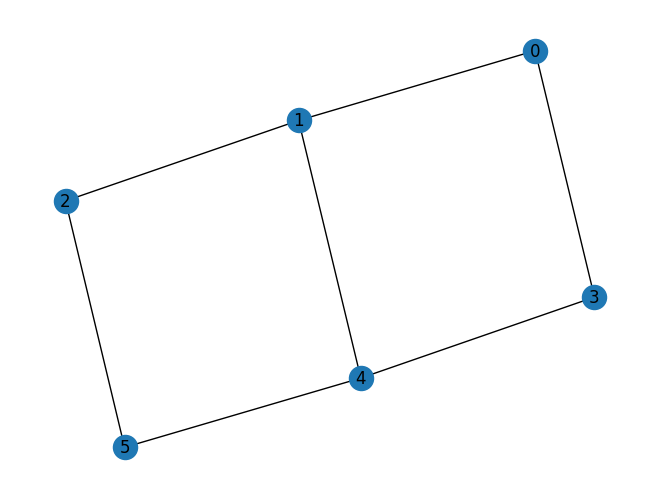

In [9]:
# =============================================================================
# LOAD NETWORK GRAPH
# =============================================================================

with open(NETWORK_GRAPH_PATH, 'rb') as f:
    network_graph = pickle.load(f)

print(f"Network nodes: {list(network_graph.nodes())}")
print(f"Network edges: {list(network_graph.edges())}")
nx.draw(network_graph, with_labels=True)

In [10]:
# =============================================================================
# GENERATE ALL MULTI-HOP PATHS
# =============================================================================

ALL_PATHS = []
for pair in combinations(network_graph.nodes, 2):
    paths = nx.all_simple_paths(network_graph, source=pair[0], target=pair[1], cutoff=MAX_HOPS)
    ALL_PATHS.extend([p for p in paths if len(p) > MIN_HOPS])

print(f"Total paths ({MIN_HOPS}-{MAX_HOPS} hops): {len(ALL_PATHS)}")
print(f"Sample: {ALL_PATHS[:3]}")

Total paths (2-3 hops): 24
Sample: [[0, 3, 4, 1], [0, 1, 2], [0, 1, 4, 3]]


## Circuit Builder

In [11]:
# =============================================================================
# CIRCUIT BUILDER
# =============================================================================

def build_913_swap_circuit(path: list, initial_state: str = '0') -> QuantumCircuit:
    """
    Build a [[9,1,3]] encode-swap-syndrome circuit.
    
    Protocol:
        1. Encode logical qubit at source
        2. SWAP along path to sink
        3. Measure syndrome at sink
    
    Args:
        path: List of node IDs, e.g., [0, 1, 2]
        initial_state: '0' or '1'
    
    Returns:
        QuantumCircuit with syndrome measurement
    """
    source = path[0]
    sink = path[-1]
    
    # Get qubit assignments
    source_qubits = get_node_qubits_913(source)
    sink_qubits = get_node_qubits_913(sink)
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_913)
    syndrome_reg = ClassicalRegister(NUM_SYNDROME_BITS, name=f'syndrome_{sink}')
    qc.add_register(syndrome_reg)
    
    # ===================
    # 1. ENCODE AT SOURCE
    # ===================
    if initial_state == '1':
        qc.x(source_qubits['data'][0])  # Logical qubit is index 0
    
    apply_encoding_913(qc, source_qubits['data'])
    qc.barrier(label='Encode')
    
    # ===================
    # 2. SWAP ALONG PATH
    # ===================
    for i in range(len(path) - 1):
        src_node = path[i]
        dst_node = path[i + 1]
        
        src_data = get_node_qubits_913(src_node)['data']
        dst_data = get_node_qubits_913(dst_node)['data']
        path_qubits = get_path_qubits_913(src_node, dst_node)
        
        apply_swap_along_edge(qc, src_data, dst_data, path_qubits)
    
    qc.barrier(label='Swap')
    
    # ===================
    # 3. SYNDROME AT SINK
    # ===================
    apply_syndrome_measurement_913(
        qc,
        sink_qubits['data'],
        sink_qubits['ancilla'],
        syndrome_reg
    )
    
    return qc

## Test Circuit

In [12]:
# =============================================================================
# TEST CIRCUIT
# =============================================================================

test_path = [0, 1, 2]
test_circuit = build_913_swap_circuit(test_path, initial_state='0')

print(f"Path: {test_path}")
print(f"Qubits: {test_circuit.num_qubits}")
print(f"Classical bits: {test_circuit.num_clbits}")
print(f"Gate counts: {test_circuit.count_ops()}")

Path: [0, 1, 2]
Qubits: 140
Classical bits: 8
Gate counts: OrderedDict({'swap': 36, 'cx': 32, 'reset': 8, 'measure': 8, 'h': 7, 'barrier': 2})


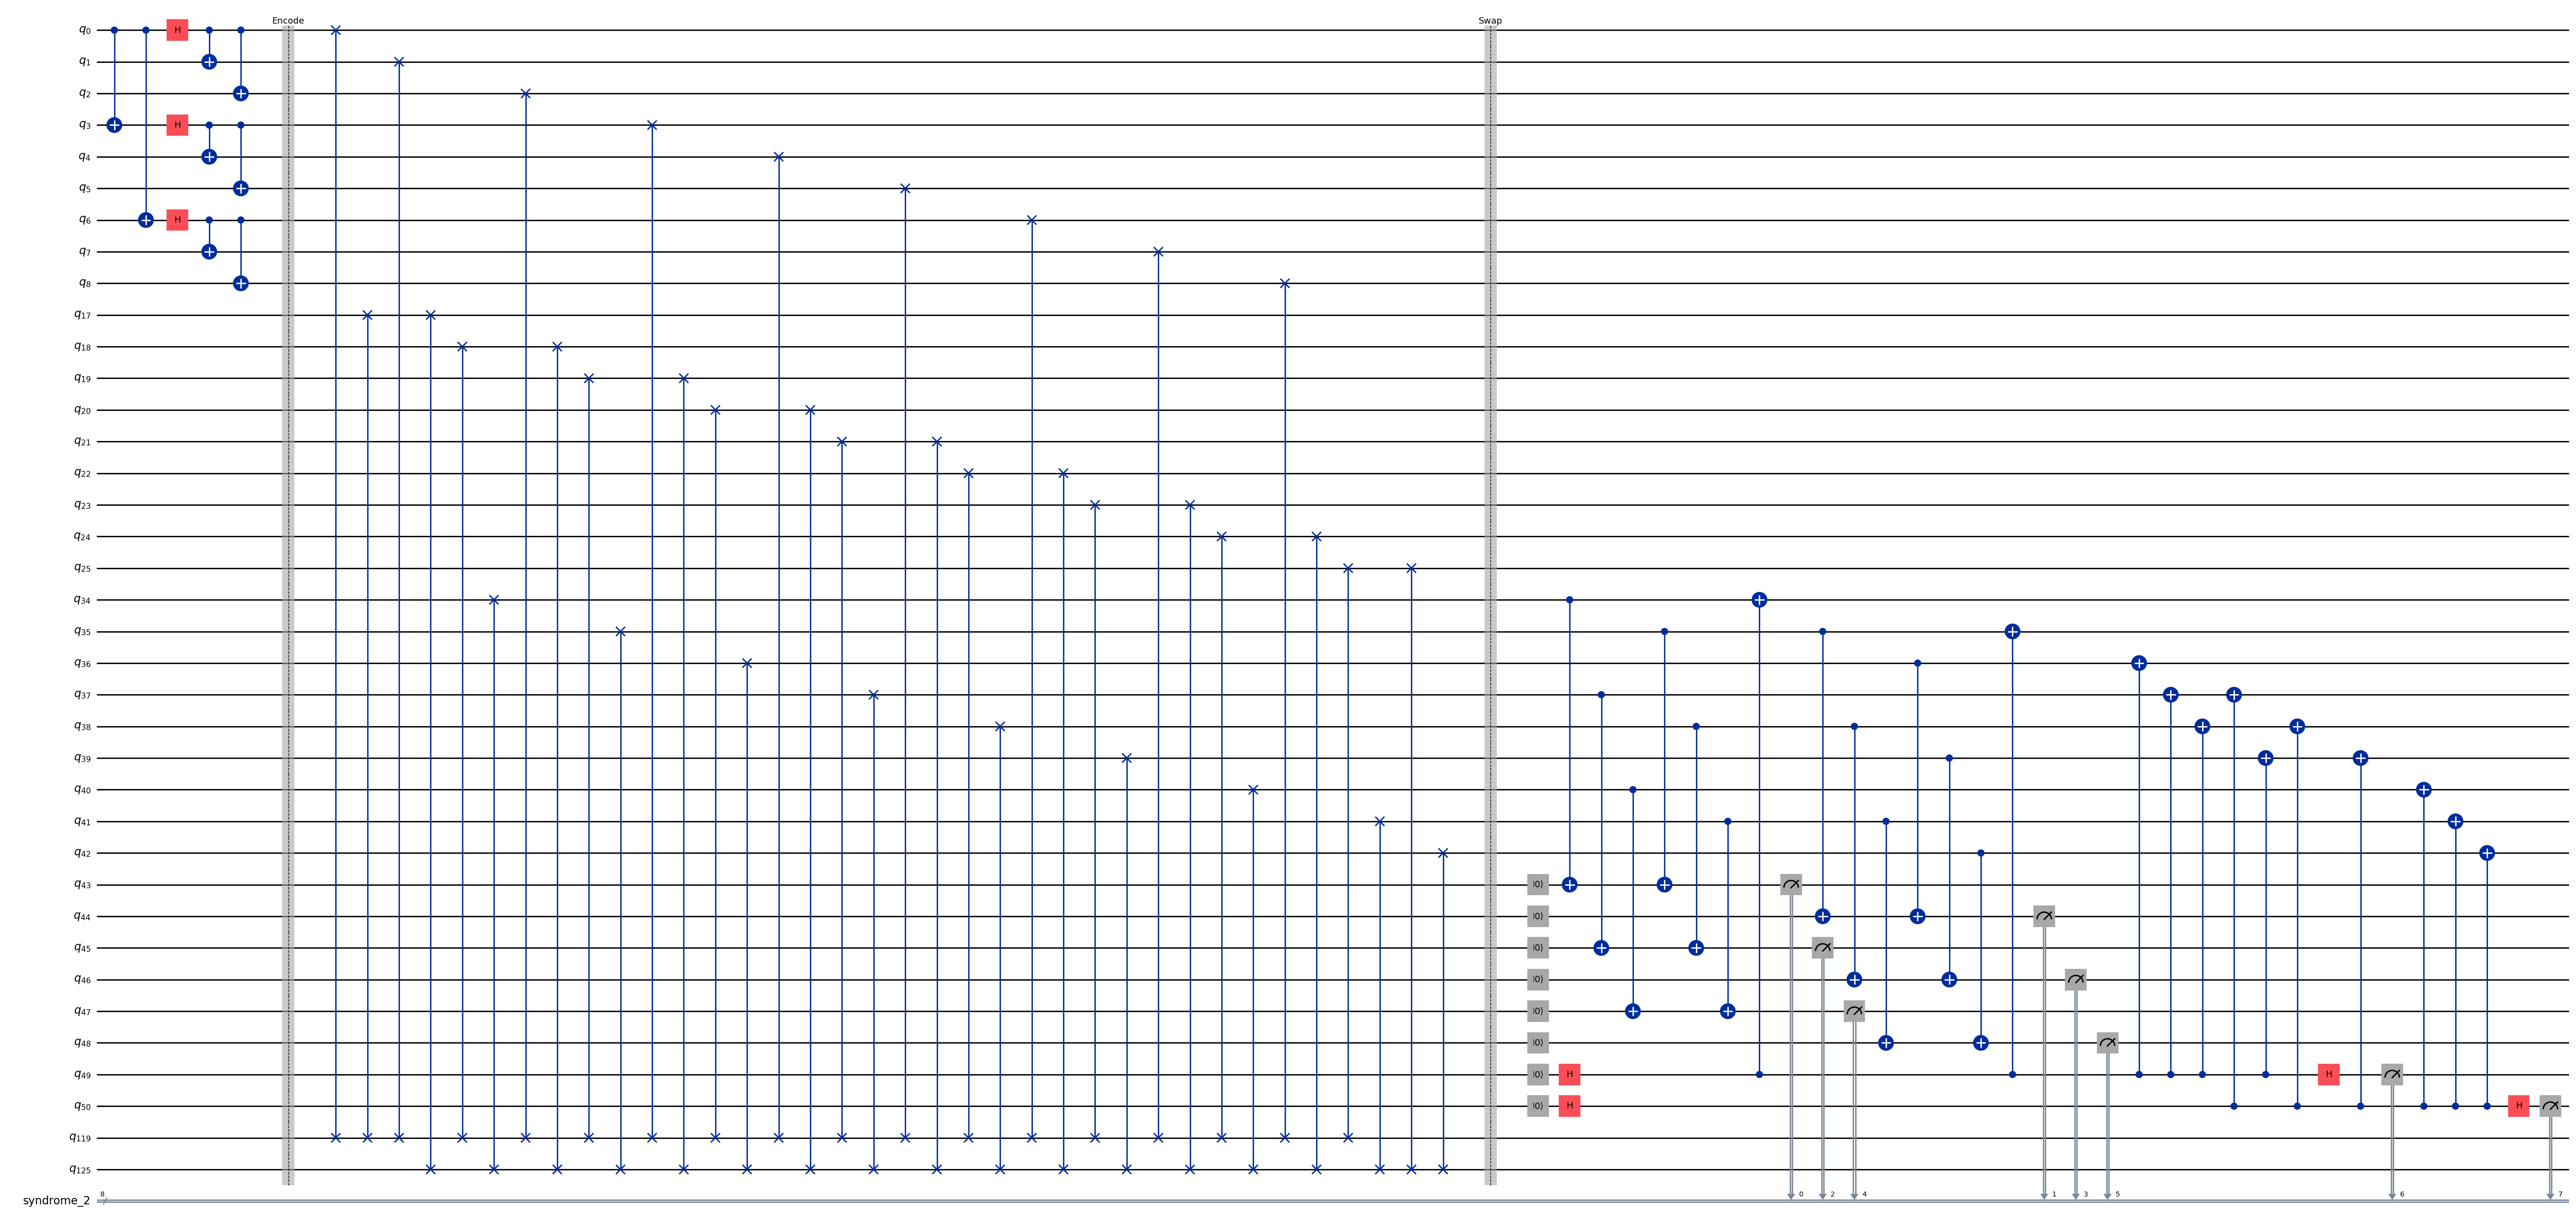

In [13]:
test_circuit.draw('mpl', fold=-1, idle_wires=False)

Noiseless syndrome counts: {'00000000': 4096}
Expected: all '00000000' (no errors)


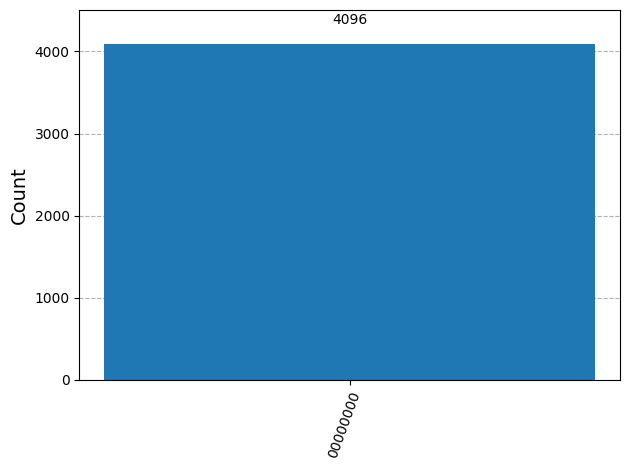

In [14]:
# =============================================================================
# NOISELESS SIMULATION
# =============================================================================

simulator = AerSimulator(method='matrix_product_state')
transpiled = transpile(test_circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

result = simulator.run(transpiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

print(f"Noiseless syndrome counts: {counts}")
print(f"Expected: all '00000000' (no errors)")
plot_histogram(counts)

Noisy syndrome counts (top 10):
  00000000: 3727 (90.99%)
  01000000: 63 (1.54%)
  10000000: 38 (0.93%)
  11000000: 38 (0.93%)
  01000011: 27 (0.66%)
  00000011: 21 (0.51%)
  10010000: 16 (0.39%)
  01000010: 16 (0.39%)
  00001100: 14 (0.34%)
  10110000: 12 (0.29%)


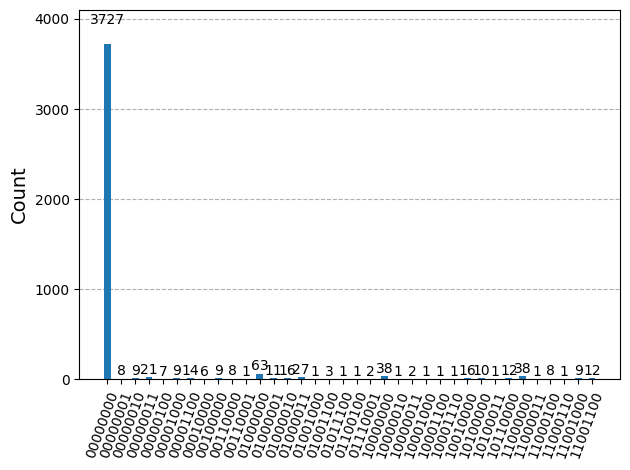

In [15]:
# =============================================================================
# NOISY SIMULATION
# =============================================================================

noisy_simulator = AerSimulator(noise_model=noise_model, method='matrix_product_state')

noisy_result = noisy_simulator.run(transpiled, shots=NUM_SHOTS).result()
noisy_counts = noisy_result.get_counts()

print("Noisy syndrome counts (top 10):")
sorted_counts = dict(sorted(noisy_counts.items(), key=lambda x: x[1], reverse=True)[:10])
for syndrome, count in sorted_counts.items():
    print(f"  {syndrome}: {count} ({count/NUM_SHOTS*100:.2f}%)")
plot_histogram(noisy_counts)

## Data Generation

In [ ]:
# =============================================================================
# DATA GENERATION
# =============================================================================

# Setup simulator
noisy_sim = AerSimulator(noise_model=noise_model, method='matrix_product_state')

measurements = []

print("=" * 60)
print("[[9,1,3]] SHOR CODE SYNDROME DATA GENERATION")
print("=" * 60)
print(f"Paths to process: {len(ALL_PATHS)}")
print("=" * 60)

for idx, path in enumerate(ALL_PATHS):
    print(f"\n[{idx+1}/{len(ALL_PATHS)}] Path: {path}")
    
    # Build and transpile
    circuit = build_913_swap_circuit(path, initial_state='0')
    transpiled = transpile(circuit, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    
    # Run
    result = noisy_sim.run(transpiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    # Build histogram - entries ordered by syndrome value (00000000, 00000001, ..., 11111111)
    histogram = np.array(
        [counts.get(f"{i:08b}", 0) for i in range(NUM_SYNDROMES)],
        dtype=np.float32
    )
    
    # Store
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    measurements.append(
        TimeAwareMeasurement(path_edges, histogram, duration=0.0, latency_stats={}, code_type='913'))
    
    no_error_frac = histogram[0] / histogram.sum()
    print(f"  Edges: {path_edges}")
    print(f"  No-error fraction: {no_error_frac:.4f}")

print(f"\n{'=' * 60}")
print(f"Total measurements: {len(measurements)}")
print(f"{'=' * 60}")

## Ground Truth

In [ ]:
# =============================================================================
# GROUND TRUTH CIRCUIT (SWAP-based transport)
# =============================================================================

def build_ground_truth_circuit(source, sink, initial_state='0', measurement_basis='Z'):
    """
    Build a ground truth circuit for single-qubit transport using SWAP chains.
    
    This circuit transports a SINGLE (unencoded) qubit from source to sink
    and measures in the specified basis to determine error rates.
    
    Protocol:
        1. Prepare qubit at source in measurement_basis
        2. SWAP through path qubits to sink
        3. Rotate back to Z-basis and measure
    
    Args:
        source: Source node ID
        sink: Sink node ID
        initial_state: '0' or '1'
        measurement_basis: 'X', 'Y', or 'Z'
    
    Returns:
        QuantumCircuit with measurement
    """
    # Get physical qubit indices
    source_qubits = NODE_PHYSICAL_QUBITS_913[source]
    sink_qubits = NODE_PHYSICAL_QUBITS_913[sink]
    
    # Get path qubit(s) for this edge
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS_913[edge_key]
    
    # Create circuit
    qc = QuantumCircuit(TOTAL_QUBITS_913)
    
    # Data qubit is at index 0 within each node's allocation
    source_qubit = source_qubits[0]
    sink_qubit = sink_qubits[0]
    
    # Prepare initial state
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)

    # Swapping path from source to sink
    num_path_qubits = len(path_qubits)
    qc.swap(source_qubit, path_qubits[0])
    for j in range(num_path_qubits - 1):
        qc.swap(path_qubits[j], path_qubits[j + 1])
    qc.swap(path_qubits[num_path_qubits - 1], sink_qubit)
    
    # Add classical register for measurement
    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotate back before measurement
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])

    return qc


def calculate_exact_pauli_rates(z_basis_counts, x_basis_counts, y_basis_counts, expected_state='0'):
    """
    Calculate exact Pauli error rates from three-basis measurements.
    
    For a qubit prepared in |0⟩ and measured in three bases:
    - Z-basis error (measure '1'): X or Y error occurred
    - X-basis error (measure '1'): Z or Y error occurred  
    - Y-basis error (measure '1'): X or Z error occurred
    
    Solving the system:
        E_z = p_x + p_y
        E_x = p_y + p_z
        E_y = p_x + p_z
    
    Gives:
        p_x = (E_z + E_y - E_x) / 2
        p_y = (E_z + E_x - E_y) / 2
        p_z = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: {'0': n0, '1': n1} from Z-basis measurement
        x_basis_counts: {'0': n0, '1': n1} from X-basis measurement
        y_basis_counts: {'0': n0, '1': n1} from Y-basis measurement
        expected_state: '0' or '1' - the state we prepared
    
    Returns:
        dict with keys 'p_x', 'p_y', 'p_z', 'E_x', 'E_y', 'E_z'
    """
    error_outcome = '1' if expected_state == '0' else '0'
    
    total_z = sum(z_basis_counts.values())
    total_x = sum(x_basis_counts.values())
    total_y = sum(y_basis_counts.values())
    
    E_z = z_basis_counts.get(error_outcome, 0) / total_z
    E_x = x_basis_counts.get(error_outcome, 0) / total_x
    E_y = y_basis_counts.get(error_outcome, 0) / total_y
    
    # Solve for individual Pauli error rates
    p_x = max(0, (E_z + E_y - E_x) / 2)
    p_y = max(0, (E_z + E_x - E_y) / 2)
    p_z = max(0, (E_x + E_y - E_z) / 2)
    
    return {
        'p_x': p_x,
        'p_y': p_y,
        'p_z': p_z,
        'E_x': E_x,
        'E_y': E_y,
        'E_z': E_z
    }

In [ ]:
# =============================================================================
# GROUND TRUTH DATA GENERATION
# =============================================================================
# Generate Pauli error rates for each edge using SWAP-based transport

GROUND_TRUTH_DATA = {}

print("=" * 70)
print("GROUND TRUTH DATA GENERATION (SWAP-based)")
print("=" * 70)
print(f"Using SWAP transport protocol with basis gate decomposition")
print(f"Basis gates: {BASIS_GATES}")
print(f"Edges to process: {list(network_graph.edges())}")
print("=" * 70)

for edge in network_graph.edges():
    print(f"\nEdge {edge}:")
    print(f"  Source qubits: {NODE_PHYSICAL_QUBITS_913[edge[0]][0]}-{NODE_PHYSICAL_QUBITS_913[edge[0]][-1]}")
    print(f"  Sink qubits: {NODE_PHYSICAL_QUBITS_913[edge[1]][0]}-{NODE_PHYSICAL_QUBITS_913[edge[1]][-1]}")
    
    # Build circuits using physical qubit mapping
    circuit_Z = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_ground_truth_circuit(edge[0], edge[1], measurement_basis='Y')

    # Transpile to basis gates for proper noise application
    decomposed_Z = transpile(circuit_Z, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_X = transpile(circuit_X, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)
    decomposed_Y = transpile(circuit_Y, basis_gates=BASIS_GATES, optimization_level=OPTIMIZATION_LEVEL)

    print("  Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(noisy_sim.run(decomposed_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(noisy_sim.run(decomposed_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(noisy_sim.run(decomposed_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"  Pauli Errors: PX={error_rates['p_x']:.6f}, PY={error_rates['p_y']:.6f}, PZ={error_rates['p_z']:.6f}")
    print(f"  Raw error rates: E_x={error_rates['E_x']:.6f}, E_y={error_rates['E_y']:.6f}, E_z={error_rates['E_z']:.6f}")

print(f"\n{'=' * 70}")
print("Ground truth data collection complete")
print(f"{'=' * 70}")

## Save Data

In [ ]:
# =============================================================================
# SAVE DATA
# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(OUTPUT_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(measurements, f)

with open(os.path.join(OUTPUT_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)

with open(os.path.join(OUTPUT_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

print(f"Data saved to {OUTPUT_DIR}")
print(f"  - measurements.pkl ({len(measurements)} measurements)")
print(f"  - graph.pkl")
print(f"  - ground_truth.pkl ({len(GROUND_TRUTH_DATA)} edges)")
print(f"\nGround truth summary:")
for edge, rates in GROUND_TRUTH_DATA.items():
    print(f"  Edge {edge}: PX={rates[0]:.6f}, PY={rates[1]:.6f}, PZ={rates[2]:.6f}")

## Analysis Summary

In [ ]:
# =============================================================================
# ANALYSIS SUMMARY
# =============================================================================

# Find paths with low no-error fraction
print("\n" + "=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

no_error_fractions = [(m.path_edges, m.histogram[0] / m.histogram.sum()) for m in measurements]
no_error_fractions.sort(key=lambda x: x[1])

print("\nTop 10 lowest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[:10]:
    print(f"  {edges}: {frac:.4f}")

print("\nTop 10 highest no-error fraction paths:")
print("-" * 40)
for edges, frac in no_error_fractions[-10:]:
    print(f"  {edges}: {frac:.4f}")

# Check for paths below threshold
threshold = 0.8
low_performance = [(edges, frac) for edges, frac in no_error_fractions if frac < threshold]
print(f"\nPaths with no-error fraction < {threshold}: {len(low_performance)}")
for edges, frac in low_performance:
    print(f"  {edges}: {frac:.4f}")